In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from sklearn.inspection import partial_dependence
import xgboost as xgb
import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Dataset

We use the **Breast Cancer Wisconsin (Diagnostic)** dataset, shipped with scikit-learn. Each row is a
digitised image of a breast mass, described by 30 numerical features computed from the cell nuclei
(radius, texture, perimeter, area, smoothness, concavity, ...), each reported as a `mean`, `standard
error`, and `worst` (largest) value across the cells in the image.

The original target has `0 = malignant`, `1 = benign`. We flip it so that **`1` means malignant** —
the class you actually want to catch — which makes every SHAP value in this notebook read as "pushes
risk up" (positive) or "pushes risk down" (negative), instead of the opposite.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.frame.drop(columns=["target"])
y = 1 - data.frame["target"]  # 1 = malignant

print(f"{X.shape[0]} rows, {X.shape[1]} features")
print(f"Malignant rate: {y.mean():.1%}")
X.head()

569 rows, 30 features
Malignant rate: 37.3%


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Train / test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {X_train.shape}  |  malignant rate: {y_train.mean():.1%}")
print(f"Test : {X_test.shape}  |  malignant rate: {y_test.mean():.1%}")

Train: (455, 30)  |  malignant rate: 37.4%
Test : (114, 30)  |  malignant rate: 36.8%


---

## 1. Fit a baseline XGBoost classifier

Nothing special here — a standard gradient-boosted tree classifier, no constraints yet. This is the
model we will spend the rest of the notebook explaining.

Malignant cases are the minority class here (roughly 37% of rows), so we score the model with
**PR AUC (average precision)** rather than ROC AUC. ROC AUC's false-positive rate is computed
against the (larger) negative class and stays flattering even when a model is mediocre at ranking
the minority class; PR AUC is graded against the positive class directly, and its baseline is the
prevalence itself rather than a fixed 0.5 — a more honest number to report for an imbalanced
diagnostic problem like this one. (See the [previous article on classification metrics](../2-classification-metrics)
for the full argument.)

In [4]:
BASE_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_SEED,
    eval_metric="logloss",
)

model_base = xgb.XGBClassifier(**BASE_PARAMS)
model_base.fit(X_train, y_train)

pr_auc_base = average_precision_score(y_test, model_base.predict_proba(X_test)[:, 1])
print(f"Test PR AUC (average precision): {pr_auc_base:.4f}")
print(f"Baseline for PR AUC (prevalence): {y_test.mean():.4f}")

Test PR AUC (average precision): 0.9926
Baseline for PR AUC (prevalence): 0.3684


---

## 2. What a SHAP value actually is

XGBoost (or any gradient-boosted model) will happily give you a prediction. It will not, on its own,
tell you *why* it produced that particular number for that particular row. That is the gap SHAP fills.

**SHAP (SHapley Additive exPlanations)** borrows the Shapley value from cooperative game theory:
treat each feature as a "player" contributing to the "payout" (the prediction), and split that payout
fairly across the players based on their marginal contribution across every possible ordering in
which they could be added. The result is a set of per-feature, per-row contributions that are
**additive**:

```
f(x) = base_value + Σ shap_value(feature_i)
```

`base_value` is the average model output over the training set (what you'd predict knowing nothing
about the row); each `shap_value` moves the prediction up or down from there. Sum them all up and you
get back the model's exact output for that row — not an approximation.

For tree ensembles specifically, `shap.TreeExplainer` computes these values **exactly** in polynomial
time by exploiting the tree structure, rather than the exponential brute-force game-theory
computation (or the sampling-based approximation `KernelExplainer` needs for arbitrary black-box
models). This is the main reason SHAP and gradient boosting are used together so often: for trees,
"exact and interpretable" is not a trade-off.

In [5]:
explainer = shap.TreeExplainer(model_base)
shap_values = explainer(X_test)

print(shap_values.shape)  # (rows, features)
print(f"Base value (log-odds): {shap_values.base_values[0]:.4f}")

(114, 30)
Base value (log-odds): -0.5064


---

## 3. The global view: the beeswarm plot

The beeswarm plot is the single most useful SHAP chart for understanding a model overall. Every dot is
one row from the test set. The row's position on the x-axis is its SHAP value (how much that feature
pushed *this* prediction); its colour is the feature's own value (red = high, blue = low); features
are ranked top-to-bottom by overall impact.

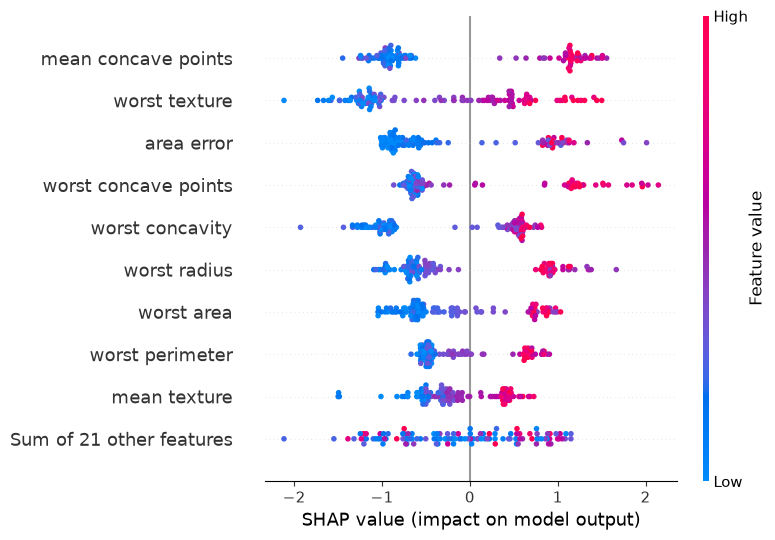

In [6]:
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig("img/beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

Reading it top to bottom:

- **`mean concave points`** is the single most influential feature. High values (red, cell boundaries
  with many concave sections) push hard toward malignant; low values (blue) push hard toward benign —
  and the two clusters barely overlap.
- **`worst texture`** is the only top feature with points spread across the *whole* colour range at
  both ends of the x-axis — a hint that its relationship with risk is less clean than the purely
  geometric features. Not every feature the model relies on behaves as tidily as the top one.
- The colour bands separate cleanly for most top features (`area error`, `worst concave points`,
  `worst concavity`, `worst radius`, ...): red on the risk-increasing side, blue on the risk-decreasing
  side. That consistent separation is what "the model learned a sensible, monotonic-looking pattern"
  looks like — for most features, most of the time.

The beeswarm plot is a great overview, but it can't answer three questions that come up constantly
once you're actually debugging a model: *does a feature's push toward risk actually line up with the
true outcome, or does it just look clean?*, *do groups of similar patients get explained the same
way?*, and *is this specific feature's relationship with risk actually as clean as it looks, or is
another feature quietly interacting with it?* The next three plots answer exactly those three
questions, in that order.

### 3a. Checking a feature against the ground truth: the label-coloured scatter

The beeswarm colours each dot by the feature's *own value* — good for reading the trend, silent on
whether that trend actually tracks the true diagnosis. Keep the same axes (one feature's value against
its own SHAP value) but colour by the **true label** instead, and the plot answers a sharper question:
for this feature alone, does a push toward malignant actually line up with malignant patients, or is it
a smooth-looking trend with the two classes tangled up inside it?

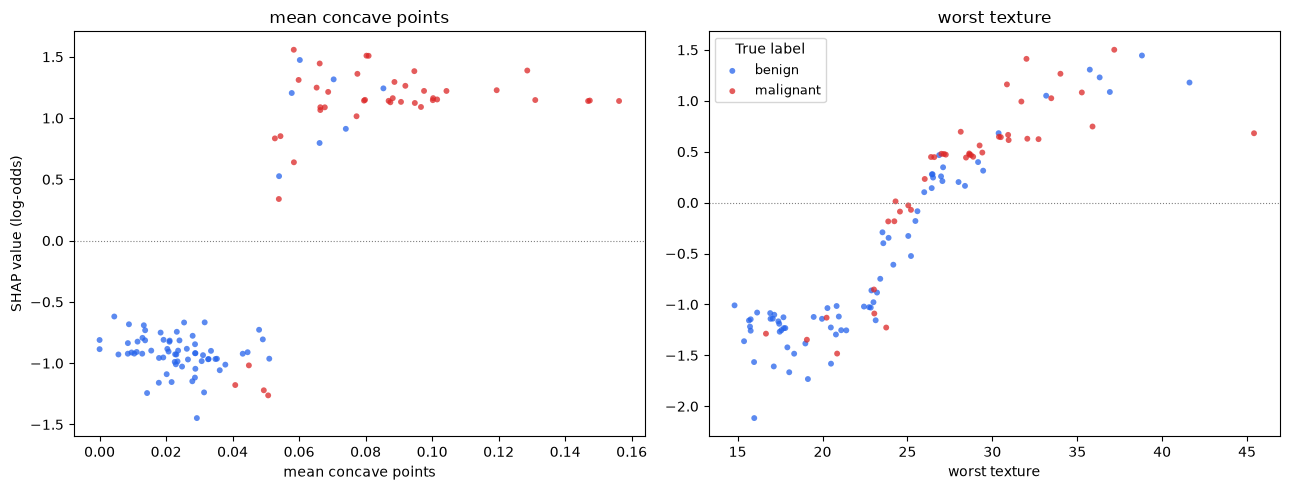

mean concave points: sign(SHAP) alone matches the true label on 90.4% of test rows
worst texture: sign(SHAP) alone matches the true label on 71.9% of test rows


In [7]:
LABEL_SCATTER_FEATURES = ["mean concave points", "worst texture"]
label_colors = {0: "#2563eb", 1: "#dc2626"}
label_names = {0: "benign", 1: "malignant"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feature in zip(axes, LABEL_SCATTER_FEATURES):
    feature_values = X_test[feature].values
    feature_shap = shap_values[:, feature].values

    for label in (0, 1):
        mask = y_test.values == label
        ax.scatter(
            feature_values[mask], feature_shap[mask],
            s=18, alpha=0.75, color=label_colors[label],
            label=label_names[label], edgecolors="none",
        )
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel(feature)
    ax.set_title(feature)

axes[0].set_ylabel("SHAP value (log-odds)")
axes[1].legend(title="True label", loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("img/label_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

for feature in LABEL_SCATTER_FEATURES:
    feature_shap = shap_values[:, feature].values
    agreement = ((feature_shap > 0) == (y_test.values == 1)).mean()
    print(f"{feature}: sign(SHAP) alone matches the true label on {agreement:.1%} of test rows")

`mean concave points` splits almost perfectly along the colour: below the gap in the trend (around
0.05) the points are almost entirely benign (blue), above it almost entirely malignant (red). This
one feature's sign alone — nothing else about the patient — agrees with the true label on **90.4%**
of test rows.

`worst texture` shows exactly the smooth, monotonic-looking climb its colour implied in the beeswarm —
no jump, no gap. But look at the middle of the range (roughly 20–30): benign (blue) and malignant (red)
patients sit on top of each other for the whole stretch, and the feature's sign alone agrees with the
true label on only **71.9%** of rows. The beeswarm's "both colours everywhere" observation wasn't just
the interacting feature muddying the picture — for `worst texture`, unlike `mean concave points`, this
one feature genuinely doesn't separate the two classes on its own. That's not a flaw in the model — the
other 29 features fill the gap — but it's exactly the kind of feature worth watching for a hidden local
reversal, the concern section 6's monotonic constraint is built to rule out.

### 3b. Spotting patterns across patients: the heatmap plot

`shap.plots.heatmap` puts every test-set row along the x-axis (clustered so that similarly-explained
rows sit next to each other) and every feature along the y-axis, colouring each cell by that feature's
SHAP value for that row. The thin line along the top traces `f(x)` — the model's actual output — for
each column, so you can see explanation patterns and output level move together.

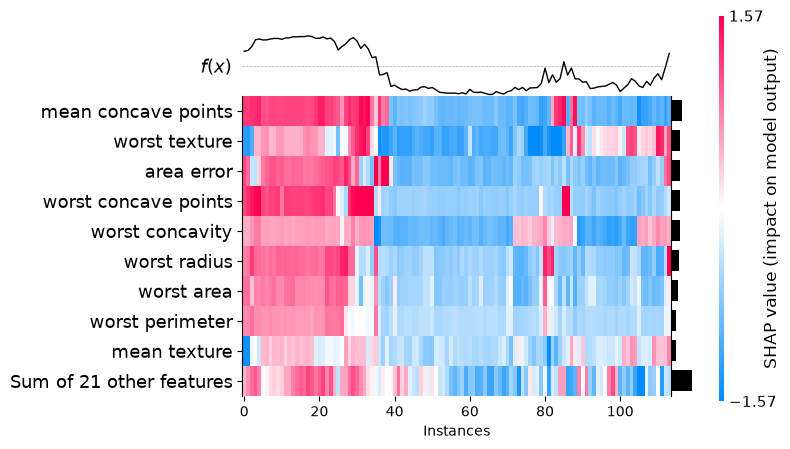

In [8]:
shap.plots.heatmap(shap_values, show=False)
plt.tight_layout()
plt.savefig("img/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Two clear blocks emerge: a left block where `mean concave points`, `area error`, `worst concave
points`, `worst radius`, and friends are all firmly red (pushing malignant) and `f(x)` sits high, and
a much wider right block where the same features are blue and `f(x)` sits low. That's the model
learning one dominant, coherent axis of risk. `worst texture`'s row is visibly messier than its
neighbours even within those blocks — more short blue/red streaks breaking up the pattern — which is
the heatmap surfacing the same thing the beeswarm plot did, from a different angle. This is the kind
of view worth checking before shipping a model: a heatmap with several distinct, unexplained blocks
(rather than one dominant pattern) is often a sign the model is doing something different for a
subgroup you haven't identified yet.

### 3c. Debugging one feature at a time: the dependence plot

`shap.plots.scatter` plots one feature's value against its own SHAP value — the "does this feature's
effect actually look like what I'd expect" view. Colour it by SHAP's automatically-selected strongest
interacting feature, and it doubles as an interaction detector: if the colour band is *not* uniform at
a given x position, the feature is doing something in combination with another one, not on its own.

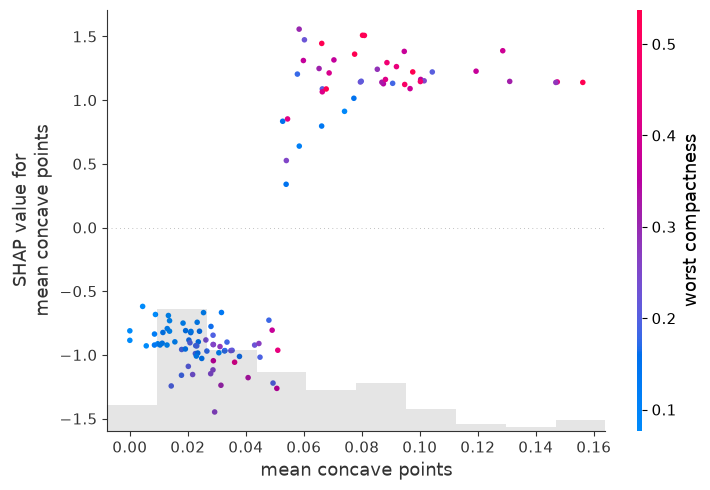

In [9]:
shap.plots.scatter(shap_values[:, "mean concave points"], color=shap_values, show=False)
plt.tight_layout()
plt.savefig("img/dependence.png", dpi=150, bbox_inches="tight")
plt.show()

`mean concave points` shows a clean two-cluster jump from strongly-negative to strongly-positive
SHAP values, exactly matching the beeswarm's story. SHAP picked `worst compactness` as the strongest
interaction: within the malignant cluster, higher `worst compactness` (pink) tends to sit at the upper
end of the SHAP range — a secondary effect you would not see in the beeswarm or bar plot at all, since
both collapse every feature down to its own axis. This combination — one feature's own effect, plus
whichever other feature modulates it — is exactly the kind of thing worth checking for every important
feature before trusting a model in production.

---

## 4. Ranked importance: the bar plot

The bar plot collapses the beeswarm down to one number per feature: the mean absolute SHAP value
across the test set. You lose the direction and the distribution — but for a quick "what matters most"
answer, or a slide with too little room for a beeswarm, it's the right tool.

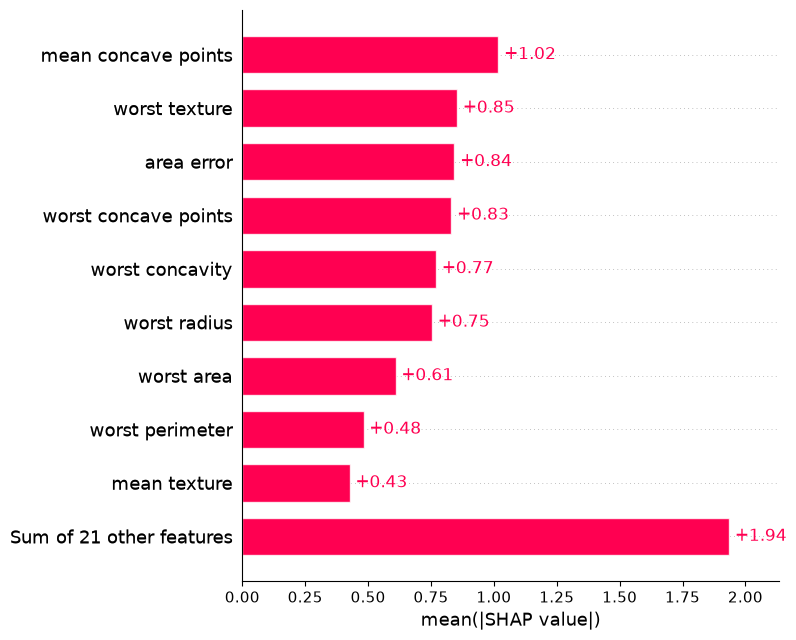

In [10]:
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("img/bar.png", dpi=150, bbox_inches="tight")
plt.show()

Same ranking as the beeswarm, as it should be — it's derived from the same numbers. Notice how much
is left on the table by only keeping the top 9: the "sum of 21 other features" bar is the single
largest bar in the chart. No individual feature outside the top 9 matters much, but collectively the
long tail is not negligible. This is common in tabular data with many correlated measurements (here,
`mean`/`error`/`worst` versions of the same 10 underlying cell properties).

---

## 5. Explaining one patient: the force plot and the waterfall plot

Beeswarm, heatmap, bar, and dependence are all *global* views — they describe the model's behaviour
across the whole test set. The force plot and the waterfall plot are *local*: they explain **one**
single prediction, which is what you actually need when a clinician, underwriter, or credit officer
asks "why did the model say **this**?"

Both are direct visualisations of the additive equation from section 2: start at `base_value`, then
each feature pushes the prediction toward malignant or toward benign, and the pushes end exactly at
`f(x)`, the model's output for that row. They show the same numbers laid out differently.

We deliberately pick a **borderline** case — not a confident, obvious prediction — because that's
where seeing the individual pushes and pulls actually earns its keep.

In [11]:
PATIENT_ID = 5  # a borderline case: predicted probability far from both 0 and 1

pos = X_test.index.get_loc(PATIENT_ID)
proba = model_base.predict_proba(X_test)[pos, 1]

print(f"True label   : {'malignant' if y_test.loc[PATIENT_ID] == 1 else 'benign'}")
print(f"Predicted P(malignant): {proba:.1%}")
print()

contribs = (
    pd.Series(shap_values.values[pos], index=X.columns)
    .sort_values(key=np.abs, ascending=False)
)
print("Top contributions (SHAP value, log-odds):")
print(contribs.head(6).to_string())

True label   : malignant
Predicted P(malignant): 64.8%

Top contributions (SHAP value, log-odds):
worst concave points    1.847538
mean concave points     1.508020
worst texture          -1.226711
worst radius           -0.733440
worst concavity         0.531428
worst smoothness        0.491311


### The force plot

Contributions laid out left-to-right as arrows on a single axis, ending at `f(x)`. Good for a quick,
compact read when you only care about the overall balance of push and pull.

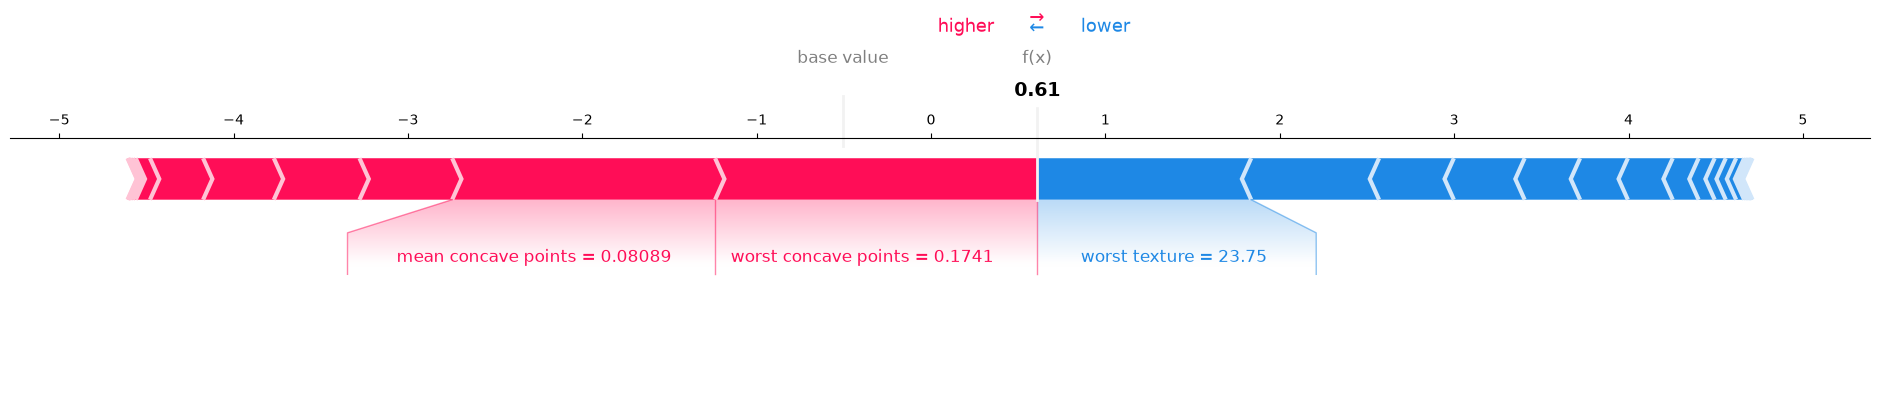

In [12]:
fig = shap.plots.force(
    shap_values[pos],
    matplotlib=True,
    show=False,
    figsize=(24, 3.5),
    contribution_threshold=0.12,
)
fig.savefig("img/force_single_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

This patient is a genuinely hard case, and the force plot shows exactly why: `mean concave points`
and `worst concave points` — both alarmingly high — push hard toward malignant, while `worst texture`
and `worst radius` — both unremarkable for this patient — pull back toward benign. The tug-of-war
lands the model at 64.8% malignant: correctly flagged as high-risk, but with visible, legitimate
uncertainty, not false confidence in either direction. That's a much more useful answer than a bare
"malignant: 65%" — it tells you *which* measurements to double-check.

### The waterfall plot

Same numbers, read top-to-bottom instead, ordered by magnitude, with every value labelled. Once a
force plot has more than a handful of meaningful contributors it starts compressing the smaller ones
into unlabelled arrows (as it just did above); the waterfall plot has room to show more of them
explicitly, which makes it the better choice when you need to hand someone an exact, auditable
breakdown rather than a quick visual balance.

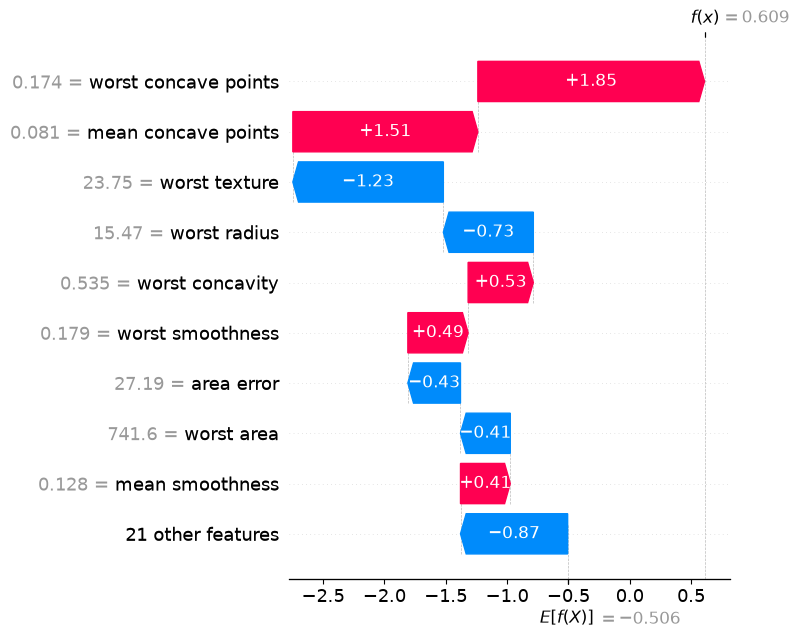

In [13]:
shap.plots.waterfall(shap_values[pos], show=False)
plt.tight_layout()
plt.savefig("img/waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

The waterfall plot tells the identical story as the force plot above, but now with two more
contributors spelled out: `worst concavity` (+0.53) and `worst smoothness` (+0.49) also lean toward
malignant, while `area error` (-0.43) and `worst area` (-0.41) lean back toward benign — detail the
force plot's compact layout had folded into "21 other features". For a one-off visual explanation the
force plot is fine; for a record you'd attach to a case file, the waterfall plot is the more complete
one.

---

## 6. When you already know the direction: monotonic constraints

Everything above *explains* a model trained the ordinary way. This section changes how it's trained.

A gradient-boosted tree learns its splits purely by minimising loss on the training sample. Nothing
stops it from learning that risk goes up, then down, then up again as a feature increases — noise in
a sparse region is enough. For a purely predictive feature that's often harmless. But for a feature
where you already know the real-world direction from domain knowledge — more concave cell boundaries
cannot make a tumour *less* suspicious, more income cannot make a borrower *less* creditworthy, all
else equal — a local reversal isn't signal the model found, it's noise the model overfit to. And it's
exactly the kind of thing that costs trust the moment a clinician or auditor notices it: *"why did
the risk score go down when this measurement got worse?"*

XGBoost's `monotone_constraints` lets you rule this out entirely: declare, per feature, that the
prediction must be non-decreasing (`1`), non-increasing (`-1`), or left alone (`0`) as that feature
increases, holding everything else fixed. It's enforced structurally while the trees are built, not
patched on afterwards.

Which features to constrain shouldn't be arbitrary. We start from features that already rank high
by SHAP, then check which of those also have a strongly monotonic relationship with the true label in
the data itself, not just in the model's output.

### Picking which features to constrain

Spearman correlation between each top-SHAP feature and the true label, computed on the training set:
a feature that already moves consistently with malignancy in the raw data is a good monotonic
constraint candidate.

In [14]:
top_cols_for_constraints = [
    "worst concave points",
    "mean concave points",
    "worst texture",
    "worst radius",

]
X_train_correlation = X_train.copy()
X_train_correlation["label"] = y_train
X_train_correlation[ top_cols_for_constraints + ["label"]].corr("spearman")

,worst concave points,mean concave points,worst texture,worst radius,label
worst concave points,1.000000,0.938175,0.356236,0.778848,0.775415
mean concave points,0.938175,1.000000,0.303568,0.794500,0.776866
worst texture,0.356236,0.303568,1.000000,0.379190,0.482408
worst radius,0.778848,0.794500,0.379190,1.000000,0.785926
label,0.775415,0.776866,0.482408,0.785926,1.000000


`worst concave points`, `mean concave points`, and `worst radius` all correlate with malignancy
above 0.77; `worst texture` more weakly, at 0.48. All four are constrained to be non-decreasing: for
each, "more of this reading should never lower the estimated risk" is a defensible clinical prior.

In [15]:
derived_relation_constraint = {
    "worst concave points":1,
    "mean concave points":1,
    "worst texture":1,
    "worst radius":1,

}

In [16]:
monotone_constraints = {col: 0 for col in X.columns}
monotone_constraints.update(derived_relation_constraint)

model_mono = xgb.XGBClassifier(**BASE_PARAMS, monotone_constraints=monotone_constraints)
model_mono.fit(X_train, y_train)

pr_auc_mono = average_precision_score(y_test, model_mono.predict_proba(X_test)[:, 1])

print(f"Test PR AUC — unconstrained : {pr_auc_base:.4f}")
print(f"Test PR AUC — monotonic     : {pr_auc_mono:.4f}")
print(f"Difference                  : {pr_auc_mono - pr_auc_base:+.4f}")

Test PR AUC — unconstrained : 0.9926
Test PR AUC — monotonic     : 0.9937
Difference                  : +0.0012


The constraint doesn't just cost nothing on held-out performance, it nudges PR AUC up slightly
(+0.0012). That's the pattern to expect when you constrain features that were already mostly
behaving: you're not fighting the data, you're removing a handful of local reversals the model
didn't need in the first place.

### Does the constraint change anything for a real patient?

Averaged over the whole test set, these features were already trending upward before the
constraint — so a global summary plot would show barely any difference. The constraint's guarantee is
narrower and more useful than that: for **any single patient**, sweeping one constrained feature up
while holding everything else about them fixed, the prediction can now only go up.

This is precisely the distinction scikit-learn's partial dependence tooling draws between two related
but different views of a feature:

- **Partial Dependence (PDP)** — the *average* effect of a feature on the prediction, marginalising
  over every other feature. This is "interpretability" in the usual global sense: on average, across
  the population, what does this feature do?
- **Individual Conditional Expectation (ICE)** — the *same* sweep, but for one specific row, with
  every other feature held at that row's actual values. This is what the feature does to *this
  patient's* predicted label, specifically.

The PDP can look perfectly smooth while individual ICE curves underneath it still misbehave — the
average hides exactly the kind of local reversal we're trying to catch. We use scikit-learn's
`partial_dependence` to compute both at once, aggregated across every patient in the test set, before
and after the constraint.

Patient 42 — true label: malignant
  worst concave points | Unconstrained model: patient 42 non-monotonic steps = 1


  worst concave points | With monotonic constraint: patient 42 non-monotonic steps = 0


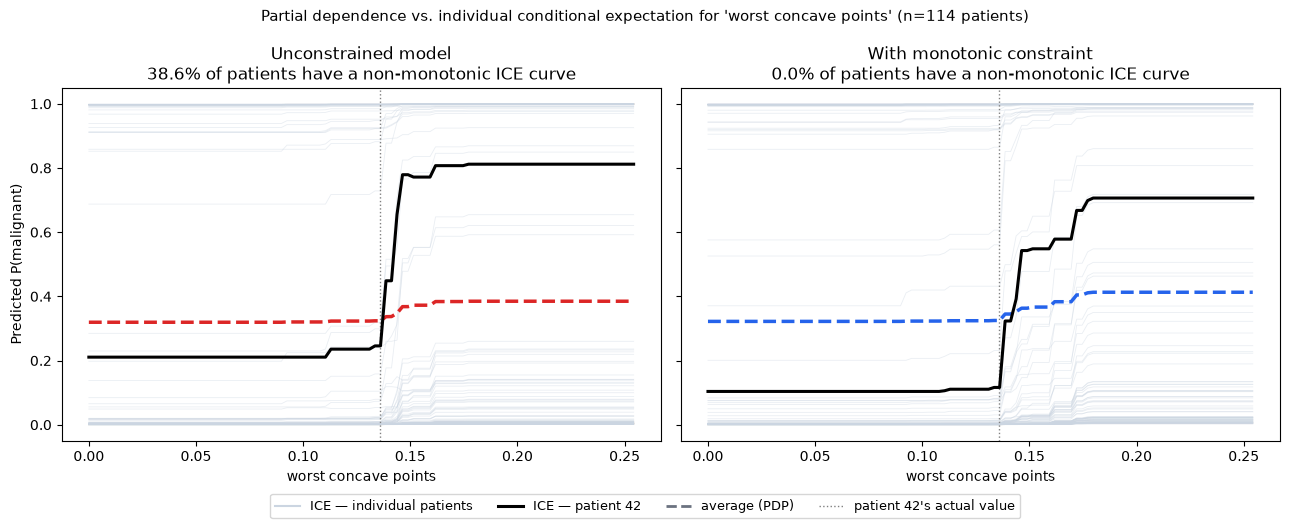

  mean concave points | Unconstrained model: patient 42 non-monotonic steps = 0


  mean concave points | With monotonic constraint: patient 42 non-monotonic steps = 0


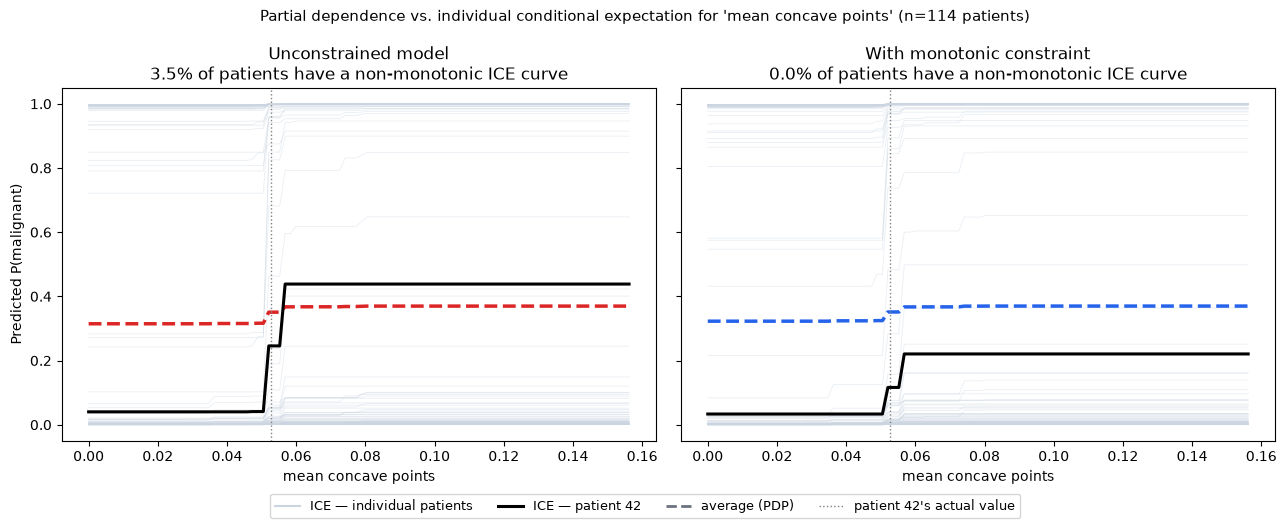

  worst texture | Unconstrained model: patient 42 non-monotonic steps = 1
  worst texture | With monotonic constraint: patient 42 non-monotonic steps = 0


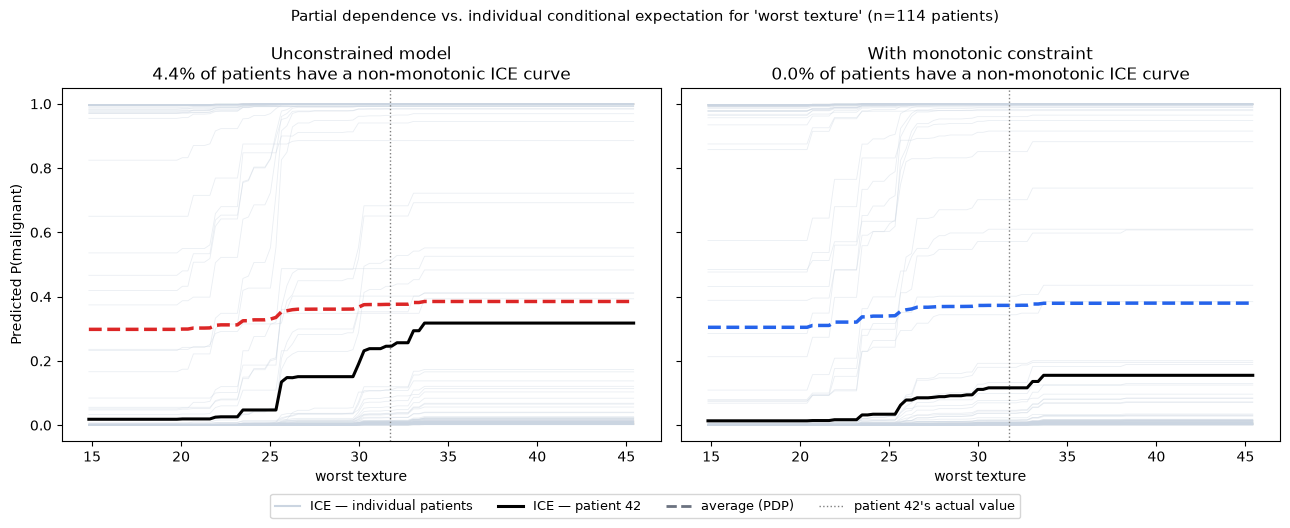

  worst radius | Unconstrained model: patient 42 non-monotonic steps = 0
  worst radius | With monotonic constraint: patient 42 non-monotonic steps = 0


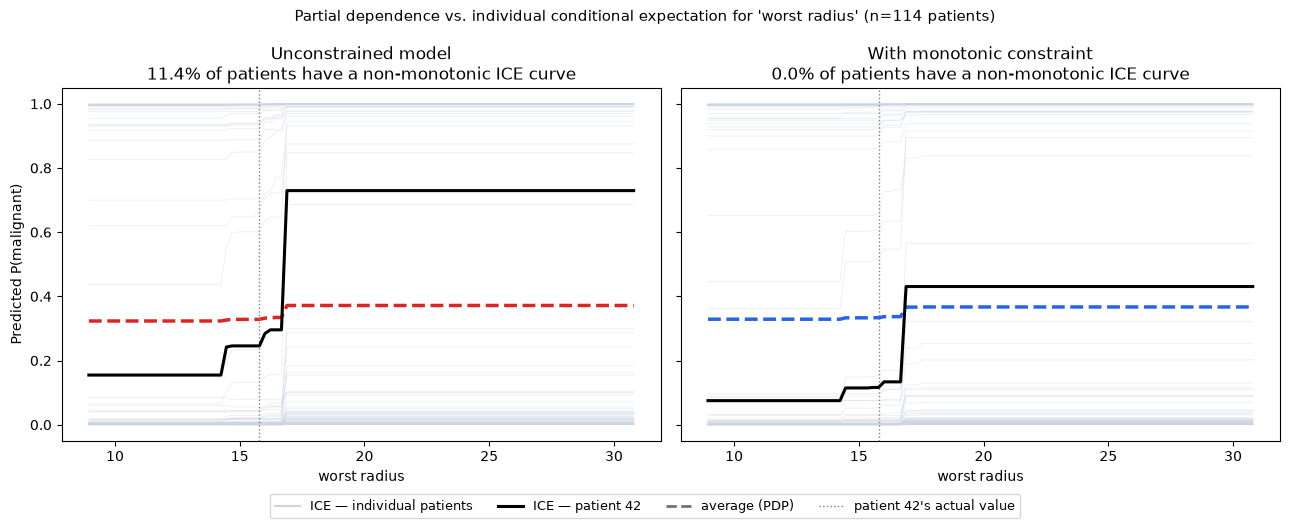

model,Unconstrained model,With monotonic constraint
feature,,
mean concave points,0.035088,0.0
worst concave points,0.385965,0.0
worst radius,0.114035,0.0
worst texture,0.043860,0.0


In [17]:
ICE_PATIENT_POS = 42  # a specific patient to trace through every constrained feature

print(f"Patient 42 — true label: {'malignant' if y_test.iloc[ICE_PATIENT_POS] == 1 else 'benign'}")

violation_summary = []

for feat in top_cols_for_constraints:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    actual_value = X_test.iloc[ICE_PATIENT_POS][feat]

    for ax, model, avg_color, title in [
        (axes[0], model_base, "#dc2626", "Unconstrained model"),
        (axes[1], model_mono, "#2563eb", "With monotonic constraint"),
    ]:
        pd_result = partial_dependence(
            model, X_test, [feat], kind="both",
            percentiles=(0, 1), grid_resolution=100, response_method="predict_proba",
        )
        grid = pd_result["grid_values"][0]
        individual = pd_result["individual"][0]  # (n_test_patients, n_grid) — one ICE curve per patient
        average = pd_result["average"][0]        # the PDP curve

        # a patient's ICE curve "violates" monotonicity if it ever dips as the feature increases
        violates = (np.diff(individual, axis=1) < -1e-9).any(axis=1)
        violation_rate = violates.mean()
        violation_summary.append({"feature": feat, "model": title, "violation_rate": violation_rate})

        n_patient_violations = np.sum(np.diff(individual[ICE_PATIENT_POS]) < -1e-9)
        print(f"  {feat} | {title}: patient 42 non-monotonic steps = {n_patient_violations}")

        for line in individual:
            ax.plot(grid, line, color="#cbd5e1", alpha=0.4, linewidth=0.6, zorder=1)
        ax.plot(grid, average, color=avg_color, linewidth=2.5, linestyle="--", zorder=2)
        ax.plot(grid, individual[ICE_PATIENT_POS], color="black", linewidth=2.2, zorder=4)
        ax.axvline(actual_value, color="gray", linestyle=":", linewidth=1, zorder=3)

        ax.set_title(f"{title}\n{violation_rate:.1%} of patients have a non-monotonic ICE curve")
        ax.set_xlabel(feat)

    axes[0].set_ylabel("Predicted P(malignant)")
    legend_handles = [
        Line2D([0], [0], color="#cbd5e1", linewidth=1.5, label="ICE — individual patients"),
        Line2D([0], [0], color="black", linewidth=2.2, label="ICE — patient 42"),
        Line2D([0], [0], color="#6b7280", linestyle="--", linewidth=2, label="average (PDP)"),
        Line2D([0], [0], color="gray", linestyle=":", linewidth=1, label="patient 42's actual value"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=9)
    fig.suptitle(
        f"Partial dependence vs. individual conditional expectation for '{feat}' (n={len(X_test)} patients)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(f"img/ice_{feat.replace(' ', '_')}_monotonic_constraint.png", dpi=150, bbox_inches="tight")
    plt.show()

violation_summary_df = (
    pd.DataFrame(violation_summary)
    .pivot(index="feature", columns="model", values="violation_rate")
    [["Unconstrained model", "With monotonic constraint"]]
)
violation_summary_df

Aggregated across all 114 test patients, local reversals in the unconstrained model are far from
rare for some features: `worst concave points`, the single most important feature by SHAP, has a
non-monotonic ICE curve for **38.6%** of patients. For over a third of the test set, holding everything
else about a patient fixed, some *worse* concave-point reading would have been read by the model as
*less* suspicious. `worst radius` shows a smaller version of the same pattern (**11.4%**); `mean concave
points` and `worst texture` were already comparatively well-behaved (3.5% and 4.4%) even before
constraining them.

After the constraint, all four features drop to **0%**, exactly as guaranteed, since
`monotone_constraints` enforces the property structurally rather than statistically. This is the trap
the aggregate view exposes that a single PDP curve can't: a smooth, upward-trending average was sitting
on top of a substantial number of patients experiencing a local dip, and no amount of staring at the
average alone would have surfaced that.

The black line traces one specific patient (position 42, actually malignant) through all four plots.
Under the unconstrained model they have a one-step reversal on two of the four features: `worst concave
points` (their actual reading, 0.136, sits just past the dip) and `worst texture` (actual reading 31.71,
same pattern), visible as the flat-then-step-back-then-climb kink in the black curve. With the
constraint, both curves become clean, non-decreasing steps for this patient too.

Their overall predicted probability moves from **24.6%** (unconstrained) to **11.6%** (constrained),
down, not up. That's a useful reminder: with four correlated features constrained together, the whole
decision surface shifts, not just the two curves that happened to misbehave for this particular
patient. Monotonic constraints guarantee well-behaved curves *per feature*; they don't guarantee any
one patient's overall score moves the direction you'd expect from watching a single feature in
isolation.

---

## What to do about it

Monotonic constraints aren't a free correctness upgrade to apply everywhere. They encode *domain
knowledge you trust more than the training data* in a specific region, so:

1. **Only constrain what you'd defend to a domain expert.** "I'm confident the real relationship is
   monotonic" is the bar — not "the dependence plot looks a little jagged." Constraining a feature
   whose true relationship *isn't* monotonic will only hurt the model.
2. **Check held-out performance before and after**, on a metric that matches the problem (PR AUC here,
   not ROC AUC). A well-chosen constraint on a feature that was already mostly monotonic should cost
   you close to nothing, as it did here. A large drop means you constrained the wrong feature, or the
   wrong direction.
3. **Look at ICE curves for individual rows, not just the average PDP.** The PDP can hide exactly the
   local reversal you're trying to catch, as it did in section 6 — a smooth average is not proof that
   every individual prediction behaves.
4. **Constraints are per-feature and independent.** Apply `monotone_constraints` only to the handful
   of features you have a real prior on; leave the rest to learn freely.

For regulated or high-stakes domains — credit scoring, medical risk, insurance pricing — where a
stakeholder can reasonably ask "why would more of a bad thing ever lower the risk score?", this is a
cheap way to make sure the model never has to answer that question.